<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/Lab7_Keras_MLP_Multiclass_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 7: Keras MLP for Multiclass Classification

Predicting the quality grade of a wine from its chemical measurements. Seven possible grades, so this is multiclass, and the network architecture is essentially the one built in Practical 4.

**That overlap is deliberate and worth stating up front.** Practical 4 was also a multiclass MLP with softmax, so simply repeating it would teach me nothing. Two things are genuinely different here:

1. **The data is real and difficult.** Practical 4 used a dataset I generated from rules I chose, so the classes were cleanly separable by construction and the model reached 96%. This one is a real dataset with severe class imbalance, overlapping classes and noisy human-assigned labels. The model reaches about 53%, and understanding *why* is the actual content of this practical.
2. **The new experimental axis is the optimizer**, which has not been compared in any previous practical.

**Pipeline:** chemical measurements, scaling, two hidden layers (activation under test), softmax over 7 classes, optimizer under test, predicted quality grade.

## Dataset description and source

**UCI Wine Quality**, physicochemical measurements of Portuguese *Vinho Verde* wines (Cortez et al., 2009). Red and white variants combined into one dataset.

Source:
`https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv`
`https://raw.githubusercontent.com/zygmuntz/wine-quality/master/winequality/winequality-white.csv`

**The classification problem:** given 11 chemical measurements plus the wine type, predict the quality grade a panel of wine tasters assigned.

**Input features:** 11 continuous chemical measurements (acidity, sugar, chlorides, sulfur dioxide, density, pH, sulphates, alcohol) plus one categorical feature, the wine type.

**Target:** `quality`, an integer grade. Each wine was graded by at least three tasters and the median of their scores was recorded, which matters later because it means the label carries human disagreement inside it.

I chose this over Iris or digits deliberately. Those datasets are cleanly separable and a model reaches high 90s without the student learning anything about *why*. This one exhibits every property the practical asks me to analyse: class imbalance, overlapping classes, label noise, and classes with too few samples to learn.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

red   = pd.read_csv("winequality-red.csv")
red.columns = [x.strip().replace('\ufeff','') for x in red.columns]
white = pd.read_csv("winequality-white.csv", sep=';')
red['wine_type'] = 'red'; white['wine_type'] = 'white'
df = pd.concat([red, white], ignore_index=True)

print("red:", red.shape, " white:", white.shape, " combined:", df.shape)
print("\ncolumns:"); print(list(df.columns))
print("\nfirst 3 rows:"); print(df.head(3).to_string())

I0000 00:00:1787585554.155049   16593 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787585554.276399   16593 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787585555.584051   16593 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


red: (1599, 13)  white: (4898, 13)  combined: (6497, 13)

columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'wine_type']

first 3 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality wine_type
0            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.51       0.56      9.4        5       red
1            7.8              0.88         0.00             2.6      0.098                 25.0                  67.0   0.9968  3.20       0.68      9.8        5       red
2            7.8              0.76         0.04             2.3      0.092                 15.0                  54.0   0.9970  3.26       0.65      9.8        5       red


In [ ]:
print("Missing values per column:")
m = df.isna().sum()
print(m[m>0] if m.sum() else "  none anywhere in the dataset")

print("\nTarget: quality")
vc = df['quality'].value_counts().sort_index()
for q,n in vc.items():
    print(f"  quality {q}: {n:>5}  ({100*n/len(df):5.2f}%)  {'#'*int(55*n/len(df))}")
print(f"\nnumber of classes            : {df['quality'].nunique()}")
print(f"imbalance ratio largest:smallest: {vc.max()/vc.min():.0f} to 1")
print(f"majority-class baseline        : {100*vc.max()/len(df):.2f}%")
print(f"\nwine_type (the categorical feature): {df['wine_type'].value_counts().to_dict()}")

Missing values per column:
  none anywhere in the dataset

Target: quality
  quality 3:    30  ( 0.46%)  
  quality 4:   216  ( 3.32%)  #
  quality 5:  2138  (32.91%)  ##################
  quality 6:  2836  (43.65%)  ########################
  quality 7:  1079  (16.61%)  #########
  quality 8:   193  ( 2.97%)  #
  quality 9:     5  ( 0.08%)  

number of classes            : 7
imbalance ratio largest:smallest: 567 to 1
majority-class baseline        : 43.65%

wine_type (the categorical feature): {'white': 4898, 'red': 1599}


#### Observation
Seven classes, and the distribution is the defining feature of this dataset.

Grades 5 and 6 together account for **76.6%** of all wines. The rarest grade, 9, has **5 rows in the entire dataset**, and grade 3 has 30. That is an imbalance ratio of **567 to 1**.

Two consequences follow immediately, and both shape everything later:

1. **The majority-class baseline is 43.65%, not 14.3%.** Always predicting grade 6 already beats random guessing by three times. Any accuracy figure has to be read against 43.65%.
2. **Some classes cannot be learned at all.** A network needs examples to learn from, and grade 9 offers four training rows. No architecture or optimizer fixes that.

No missing values anywhere, so nothing to impute. The categorical feature is `wine_type`, with 4898 white and 1599 red.

## A preprocessing decision worth measuring rather than assuming

Before anything else, a check that turns out to matter. The dataset contains repeated rows, wines whose every recorded measurement is identical.

If those are left in and the data is split randomly, **the same wine can land in both the training set and the test set**. The model then gets tested on rows it has already memorised, and the test score is inflated by leakage rather than earned by generalisation.

Dropping them is the standard advice. Rather than take that on faith, the cell below measures how much difference it actually makes.

In [ ]:
dups = df.duplicated().sum()
print(f"duplicated rows: {dups} of {len(df)}  ({100*dups/len(df):.1f}%)")
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"after dropping : {len(df_clean)} rows")

def prepare(frame, seed=42):
    d = frame.copy()
    d['wine_type'] = (d['wine_type']=='red').astype(int)     # binary categorical -> 0/1
    y_raw = d.pop('quality').values
    classes = np.unique(y_raw)
    y = np.searchsorted(classes, y_raw)                      # grades -> 0..K-1 for Keras
    X = d.values.astype('float32')
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    sc = StandardScaler().fit(Xtr)                           # fit on TRAIN only
    return (sc.transform(Xtr).astype('float32'), sc.transform(Xte).astype('float32'),
            ytr, yte, classes, list(d.columns))

def quick_model(Xtr, ytr, n_classes, seed=42, epochs=60):
    tf.keras.backend.clear_session(); tf.random.set_seed(seed)
    m = tf.keras.Sequential([tf.keras.layers.Input(shape=(Xtr.shape[1],)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(n_classes, activation='softmax')])
    m.compile(optimizer=tf.keras.optimizers.Adam(0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    m.fit(Xtr, ytr, epochs=epochs, batch_size=64, validation_split=0.2, verbose=0)
    return m

for tag, frame in (("duplicates KEPT (leaky)", df), ("duplicates DROPPED (honest)", df_clean)):
    Xtr,Xte,ytr,yte,cl,_ = prepare(frame)
    p = quick_model(Xtr,ytr,len(cl)).predict(Xte, verbose=0).argmax(1)
    print(f"{tag:<30} test accuracy {accuracy_score(yte,p):.4f}")

duplicated rows: 1177 of 6497  (18.1%)
after dropping : 5320 rows


duplicates KEPT (leaky)        test accuracy 0.5554


duplicates DROPPED (honest)    test accuracy 0.5385


#### Observation
1177 rows, **18.1% of the dataset**, are exact duplicates.

Keeping them scores 0.5554 on the test set. Dropping them scores 0.5385. So the leakage is worth **1.7 percentage points** of entirely fake accuracy, bought by testing the model on wines it had already memorised.

That is not a large number, but it is real, it is free to remove, and it points the wrong way (it flatters the model). Everything from here uses the deduplicated data. Worth noting that a student reporting the higher figure would not be lying, just measuring the wrong thing, which is exactly why this is worth checking rather than assuming.

## Preprocessing, and why each step was chosen

**1. Drop duplicate rows.** Measured above, not assumed.

**2. Missing values: none.** Checked rather than skipped. Nothing to impute.

**3. Encode the categorical feature.** `wine_type` has exactly two levels, so a single 0/1 column is sufficient and one-hot encoding would add a redundant column. For a feature with three or more unordered levels I would one-hot instead, as in Practical 6.

**4. Encode the target.** Keras needs class indices 0 to K-1, but the grades are 3 to 9. `np.searchsorted` maps them, and the original grades are kept so every table and plot can be labelled with the real quality score rather than an index. Labels stay as integers, so the loss is `sparse_categorical_crossentropy`. The one-hot equivalent would be `categorical_crossentropy`, which is the same maths with a different label format.

**5. Scale the features.** The features span very different ranges (`total sulfur dioxide` reaches 289 while `chlorides` sits near 0.05) and several are strongly right skewed. `StandardScaler` is fitted on the training set only, so no information about the test set leaks into training.

**6. Stratified split, 80/20.** Stratification is not optional here. With the rarest grade holding only a handful of rows, an unstratified split could put zero of them in the training set.

**7. Validation strategy.** A further 20% of the training set is held out by Keras as a validation split, used to watch for overfitting and compare convergence. The test set is touched only for final evaluation. Every experiment reuses the identical split, which the practical requires for fair comparison.

In [ ]:
X_train, X_test, y_train, y_test, CLASSES, FEATURES = prepare(df_clean)
N_CLASSES = len(CLASSES)
LABELS = [str(q) for q in CLASSES]

print(f"input features   : {X_train.shape[1]}  ->  {FEATURES}")
print(f"number of classes: {N_CLASSES}  (quality grades {CLASSES.tolist()})")
print(f"train / test     : {X_train.shape[0]} / {X_test.shape[0]}")
print(f"missing values   : {np.isnan(X_train).sum() + np.isnan(X_test).sum()}")
print("\ntest-set class counts:")
for i,q in enumerate(CLASSES):
    print(f"  quality {q}: {(y_test==i).sum():>4} test rows,  {(y_train==i).sum():>4} train rows")

input features   : 12  ->  ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']
number of classes: 7  (quality grades [3, 4, 5, 6, 7, 8, 9])
train / test     : 4256 / 1064
missing values   : 0

test-set class counts:
  quality 3:    6 test rows,    24 train rows
  quality 4:   41 test rows,   165 train rows
  quality 5:  350 test rows,  1402 train rows
  quality 6:  465 test rows,  1858 train rows
  quality 7:  171 test rows,   685 train rows
  quality 8:   30 test rows,   118 train rows
  quality 9:    1 test rows,     4 train rows


#### Observation
The split preserves the class proportions, and it also makes the small-class problem concrete: **grade 9 has 4 training rows and 1 test row, grade 3 has 24 and 6.**

A single test sample means the recall for that class is either 0.00 or 1.00, with nothing in between. Any macro-averaged metric will inherit that instability, which becomes important when the results are compared later.

## Baselines first

Same discipline as the previous practicals. An accuracy of 53% means nothing until I know what trivial approaches score, and with imbalanced classes the naive floor is much higher than `1/7`.

In [ ]:
maj = np.bincount(y_train).argmax()
maj_pred = np.full_like(y_test, maj)
logreg = LogisticRegression(max_iter=2000).fit(X_train, y_train)
log_pred = logreg.predict(X_test)

def line(name, pred):
    print(f"{name:<34}{accuracy_score(y_test,pred):>9.4f}"
          f"{f1_score(y_test,pred,average='macro',zero_division=0):>11.4f}"
          f"{f1_score(y_test,pred,average='weighted',zero_division=0):>12.4f}")

print(f"{'baseline':<34}{'accuracy':>9}{'macro F1':>11}{'weighted F1':>12}")
print("-"*66)
print(f"{'random guess among 7 classes':<34}{1/N_CLASSES:>9.4f}{'':>11}{'':>12}")
line(f"always predict quality {CLASSES[maj]}", maj_pred)
line("multinomial logistic regression", log_pred)

baseline                           accuracy   macro F1 weighted F1
------------------------------------------------------------------
random guess among 7 classes         0.1429                       
always predict quality 6             0.4370     0.0869      0.2658
multinomial logistic regression      0.5320     0.2309      0.5032


#### Observation
Three reference points, and the gap between them is instructive.

Random guessing across seven classes gives 14.3%, but **always predicting grade 6 gives 43.70%** without learning anything. That is the number to beat.

Multinomial logistic regression, the no-hidden-layer model used as a baseline throughout these practicals, reaches **53.20%**. So a straight-line combination of the chemical measurements already captures most of what is learnable here, and the hidden layers will have to justify themselves against 53.20%, not 43.70%.

The macro F1 column shows why accuracy alone is misleading with imbalance: the majority-class baseline scores 43.70% accuracy but a macro F1 of only **0.0869**, because it gets six of the seven classes completely wrong.

## MLP architecture

Held identical across every experiment so the comparisons are like for like. Only the activation and the optimizer change.

```
Input (12 features)
    |
Dense(64, activation under test)
    |
Dense(32, activation under test)
    |
Dense(7, softmax)              <- one neuron per class
```

| setting | value |
|---|---|
| input features | 12 |
| number of classes | 7 |
| hidden layer 1 | 64 neurons |
| hidden layer 2 | 32 neurons |
| hidden activation | ReLU / Sigmoid / Tanh (under test) |
| output activation | **softmax** |
| loss | sparse categorical crossentropy |
| optimizer | Adam / SGD / RMSprop (under test) |
| learning rate | 0.001 for Adam and RMSprop, 0.01 for SGD (their usual defaults) |
| batch size | 64 |
| epochs | 60 |
| validation | 20% of the training set |

Softmax on the output for the reason established in Practical 4: it forces the seven outputs to sum to 1, so they form a genuine probability distribution and the classes compete. Seven independent sigmoids could claim high confidence in several grades at once, which is meaningless when a wine has exactly one grade.

In [ ]:
def build(activation, optimizer_name, seed=42):
    tf.keras.backend.clear_session(); tf.random.set_seed(seed)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dense(32, activation=activation),
        tf.keras.layers.Dense(N_CLASSES, activation='softmax')])
    opt = {'adam':    tf.keras.optimizers.Adam(0.001),
           'rmsprop': tf.keras.optimizers.RMSprop(0.001),
           'sgd':     tf.keras.optimizers.SGD(0.01)}[optimizer_name]
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def evaluate(model, hist):
    p = model.predict(X_test, verbose=0).argmax(1)
    return dict(
        train_acc=hist['accuracy'][-1],   val_acc=hist['val_accuracy'][-1],
        train_loss=hist['loss'][-1],      val_loss=hist['val_loss'][-1],
        test_acc=accuracy_score(y_test,p),
        precision=precision_score(y_test,p,average='macro',zero_division=0),
        recall=recall_score(y_test,p,average='macro',zero_division=0),
        f1=f1_score(y_test,p,average='macro',zero_division=0),
        f1_weighted=f1_score(y_test,p,average='weighted',zero_division=0),
        within1=float((np.abs(p-y_test)<=1).mean()), pred=p)

def train(activation, optimizer_name, seed=42, epochs=60, class_weight=None):
    m = build(activation, optimizer_name, seed)
    h = m.fit(X_train, y_train, epochs=epochs, batch_size=64,
              validation_split=0.2, verbose=0, class_weight=class_weight)
    r = evaluate(m, h.history); r['hist'] = h.history
    return m, r

build('relu','adam').summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,143 (12.28 KB)

 Trainable params: 3,143 (12.28 KB)

 Non-trainable params: 0 (0.00 B)

## Experiment A: hidden-layer activation functions

ReLU, sigmoid and tanh, with the optimizer fixed at Adam and everything else identical.

**All metrics below are macro-averaged.** With imbalance this severe, weighted averaging mostly reports how well the model does on the two large classes and hides the rest, which is exactly what needs to be visible here. Weighted F1 is reported alongside for contrast.

In [ ]:
ACTS = ['relu','sigmoid','tanh']
actA = {}
for a in ACTS:
    _, actA[a] = train(a, 'adam')

print(f"{'activation':<11}{'train acc':>10}{'val acc':>9}{'train loss':>12}{'val loss':>10}"
      f"{'test acc':>10}{'macro P':>9}{'macro R':>9}{'macro F1':>10}{'wtd F1':>9}")
print("-"*99)
for a in ACTS:
    r = actA[a]
    print(f"{a:<11}{r['train_acc']:>10.4f}{r['val_acc']:>9.4f}{r['train_loss']:>12.4f}"
          f"{r['val_loss']:>10.4f}{r['test_acc']:>10.4f}{r['precision']:>9.4f}"
          f"{r['recall']:>9.4f}{r['f1']:>10.4f}{r['f1_weighted']:>9.4f}")

activation  train acc  val acc  train loss  val loss  test acc  macro P  macro R  macro F1   wtd F1
---------------------------------------------------------------------------------------------------
relu           0.6287   0.5340      0.8941    1.1045    0.5395   0.3401   0.2571    0.2623   0.5229
sigmoid        0.5582   0.5458      1.0406    1.0730    0.5385   0.2723   0.2276    0.2271   0.5120
tanh           0.6043   0.5469      0.9341    1.0621    0.5442   0.2678   0.2461    0.2501   0.5253


#### Observation
All three activations land within **0.6 of a percentage point** of each other on test accuracy: relu 0.5395, sigmoid 0.5385, tanh 0.5442.

The training figures are more revealing than the test ones. ReLU reaches the highest training accuracy (0.6287) and the highest training loss gap, while sigmoid reaches the lowest training accuracy (0.5582) but the **highest validation accuracy of the three** (0.5458). ReLU is fitting the training set harder without that translating into better generalisation.

Macro F1 ranks them relu 0.2623, tanh 0.2501, sigmoid 0.2271, but those differences are small enough that they need checking against run-to-run variation before anything is concluded from them. That check is two sections down, and it changes the answer.

## Experiment B: optimizers

Adam, RMSprop and plain SGD, with the activation fixed at ReLU.

**Why these three are appropriate.** All are first-order gradient methods suited to training an MLP by backpropagation, and they differ in one specific way: how the step size is chosen.

- **SGD** applies the same fixed learning rate to every weight. Simple and well understood, but a single rate has to suit every parameter at once.
- **RMSprop** keeps a running average of each weight's recent squared gradients and divides by it, so weights with consistently large gradients take smaller steps. This helps when features contribute at very different magnitudes.
- **Adam** does what RMSprop does and adds momentum, accumulating a running average of the gradient direction as well.

Since the measured effect here is on **convergence speed**, the table records how many epochs each needs to pass a given validation accuracy. The majority-class baseline is about 44%, so a threshold of 54% is meaningfully above guessing.

In [ ]:
OPTS = ['adam','rmsprop','sgd']
optB = {'adam': actA['relu']}
for o in ['rmsprop','sgd']:
    _, optB[o] = train('relu', o)

def epochs_to(hist, thresh):
    v = np.array(hist['val_accuracy']); w = np.where(v > thresh)[0]
    return str(int(w[0])+1) if len(w) else "never"

print(f"{'optimizer':<10}{'ep to val>0.50':>15}{'ep to val>0.54':>16}{'val@ep5':>10}"
      f"{'val@ep20':>10}{'test acc':>10}{'macro F1':>10}{'train-val gap':>15}")
print("-"*96)
for o in OPTS:
    r = optB[o]; h = r['hist']
    print(f"{o:<10}{epochs_to(h,0.50):>15}{epochs_to(h,0.54):>16}"
          f"{h['val_accuracy'][4]:>10.4f}{h['val_accuracy'][19]:>10.4f}"
          f"{r['test_acc']:>10.4f}{r['f1']:>10.4f}{r['train_acc']-r['val_acc']:>15.4f}")

optimizer  ep to val>0.50  ep to val>0.54   val@ep5  val@ep20  test acc  macro F1  train-val gap
------------------------------------------------------------------------------------------------
adam                    1               2    0.5516    0.5540    0.5395    0.2623         0.0946
rmsprop                 1               2    0.5599    0.5692    0.5367    0.2374         0.0582
sgd                     6              11    0.4883    0.5469    0.5423    0.2215         0.0133


#### Observation
**This is where a real difference appears, and it is in convergence speed rather than final accuracy.**

Adam and RMSprop pass 54% validation accuracy at **epoch 2**. Plain SGD needs **epoch 11**, roughly five times slower, and at epoch 5 it is still at 0.4883, below the majority-class baseline while the other two are already near their ceiling.

That is the adaptive learning rate doing its job. Adam and RMSprop scale each weight's step by its recent gradient history, so weights attached to features contributing at different magnitudes all make useful progress. SGD applies one fixed rate to everything.

**But the final scores invert the ranking.** SGD ends with the *best* test accuracy (0.5423) and by far the smallest train/validation gap (**0.0133 against Adam's 0.0946**, seven times smaller). Its slower, noisier updates act as a mild regulariser, so it fits the training set less aggressively and generalises slightly better. Fastest convergence is not the same as the best final model.

## Are those differences real? Repeating every configuration across seeds

The tables above rank five configurations that finish within about a point of each other. Before drawing any conclusion from that ordering, it has to be compared against how much the *same* configuration varies when only the random seed changes. This is the check I failed to do in Practical 4 and got a conclusion wrong as a result.

Three seeds per configuration, everything else identical.

In [ ]:
CONFIGS = [('relu','adam'),('sigmoid','adam'),('tanh','adam'),('relu','sgd'),('relu','rmsprop')]
SEEDS = [0, 1, 42]
stab = {}

for act, opt in CONFIGS:
    accs, f1s = [], []
    for s in SEEDS:
        _, r = train(act, opt, seed=s)
        accs.append(r['test_acc']); f1s.append(r['f1'])
    stab[(act,opt)] = (np.array(accs), np.array(f1s))

print(f"{'configuration':<18}{'acc mean':>10}{'acc spread':>12}{'macroF1 mean':>14}{'macroF1 spread':>16}")
print("-"*70)
for k,(a,f) in stab.items():
    print(f"{k[0]+' + '+k[1]:<18}{a.mean():>10.4f}{np.ptp(a):>12.4f}{f.mean():>14.4f}{np.ptp(f):>16.4f}")

all_acc = np.array([a.mean() for a,_ in stab.values()])
all_f1  = np.array([f.mean() for _,f in stab.values()])
print(f"\nspread of accuracy ACROSS configurations : {np.ptp(all_acc):.4f}")
print(f"largest spread WITHIN one configuration   : {max(np.ptp(a) for a,_ in stab.values()):.4f}")
print(f"\nspread of macro F1 ACROSS configurations : {np.ptp(all_f1):.4f}")
print(f"largest spread WITHIN one configuration   : {max(np.ptp(f) for _,f in stab.values()):.4f}")

configuration       acc mean  acc spread  macroF1 mean  macroF1 spread
----------------------------------------------------------------------
relu + adam           0.5451      0.0169        0.2528          0.0363
sigmoid + adam        0.5370      0.0038        0.2173          0.0037
tanh + adam           0.5417      0.0047        0.2528          0.0166
relu + sgd            0.5451      0.0056        0.2223          0.0068
relu + rmsprop        0.5432      0.0113        0.2595          0.0444

spread of accuracy ACROSS configurations : 0.0081
largest spread WITHIN one configuration   : 0.0169

spread of macro F1 ACROSS configurations : 0.0422
largest spread WITHIN one configuration   : 0.0444


#### Observation
**This result overturns the two tables above, so it is the most important cell in the notebook.**

```
spread of accuracy ACROSS the five configurations : 0.0081
largest spread WITHIN a single configuration      : 0.0169
```

Changing the random seed while keeping everything else identical moves accuracy by up to **0.0169**. The total spread between all five different configurations is **0.0081**, less than half of that.

**So the differences between the activations and optimizers are smaller than the noise.** Ranking them by test accuracy would be ranking random initialisations. The same holds for macro F1, where the within-configuration spread reaches 0.0444 against 0.0422 across configurations.

Macro F1 is the more volatile of the two (relu + rmsprop swings 0.0444, relu + adam 0.0363) for the reason set out earlier: with 1 test sample in grade 9 and 6 in grade 3, a single lucky prediction moves a whole class's recall from 0 to 1, and macro averaging gives that class the same weight as grade 6 with its 465 samples.

The honest conclusion is that **on this dataset, no activation or optimizer choice meaningfully changes final performance.** What they change is how fast training converges and how hard the model fits the training set. That is a genuine finding, not a failed experiment, and it is only visible because the configurations were repeated.

## Comparison table

In [ ]:
TABLE = [("Model 1","relu","adam"), ("Model 2","sigmoid","adam"), ("Model 3","tanh","adam"),
         ("Model 4","relu","sgd"),  ("Model 5","relu","rmsprop")]

print("All metrics macro-averaged. Mean over 3 seeds, with the spread across seeds in brackets.\n")
print(f"{'Experiment':<10}{'Activation':<11}{'Optimizer':<11}{'Test Acc':>18}{'Macro F1':>18}{'Wtd F1':>10}")
print("-"*78)
for name, act, opt in TABLE:
    a, f = stab[(act,opt)]
    w = actA[act]['f1_weighted'] if opt=='adam' else optB[opt]['f1_weighted']
    print(f"{name:<10}{act:<11}{opt:<11}"
          f"{a.mean():>11.4f} (+-{np.ptp(a)/2:.3f}){f.mean():>11.4f} (+-{np.ptp(f)/2:.3f}){w:>10.4f}")

All metrics macro-averaged. Mean over 3 seeds, with the spread across seeds in brackets.

ExperimentActivation Optimizer            Test Acc          Macro F1    Wtd F1
------------------------------------------------------------------------------
Model 1   relu       adam            0.5451 (+-0.008)     0.2528 (+-0.018)    0.5229
Model 2   sigmoid    adam            0.5370 (+-0.002)     0.2173 (+-0.002)    0.5120
Model 3   tanh       adam            0.5417 (+-0.002)     0.2528 (+-0.008)    0.5253
Model 4   relu       sgd             0.5451 (+-0.003)     0.2223 (+-0.003)    0.5143
Model 5   relu       rmsprop         0.5432 (+-0.006)     0.2595 (+-0.022)    0.5143


#### Observation
Reported as means over 3 seeds with the spread shown, because a single-run table here would invite conclusions the data does not support.

Every configuration sits between 0.5370 and 0.5451 accuracy. The error bars overlap for all five. Model 1 (relu + adam) and Model 4 (relu + sgd) are tied at 0.5451, and the highest macro F1 (Model 5, relu + rmsprop at 0.2595) carries the largest spread of any configuration (+-0.022), so its lead is not trustworthy.

Weighted F1 tells the same story from a different angle, ranging only from 0.5120 to 0.5253.

## Confusion matrix and where the errors actually are

Confusion matrix (rows = true quality, columns = predicted quality)

             3     4     5     6     7     8     9
true 3       0     2     4     0     0     0     0
true 4       0     7    28     5     1     0     0
true 5       0     6   238   100     6     0     0
true 6       0     4   129   272    60     0     0
true 7       0     0    12    98    60     1     0
true 8       0     0     1    16    13     0     0
true 9       0     0     0     1     0     0     0

              precision    recall  f1-score   support

           3      0.000     0.000     0.000         6
           4      0.368     0.171     0.233        41
           5      0.578     0.680     0.625       350
           6      0.553     0.585     0.568       465
           7      0.429     0.351     0.386       171
           8      0.000     0.000     0.000        30
           9      0.000     0.000     0.000         1

    accuracy                          0.542      1064
   macro avg      0.275     0.255 

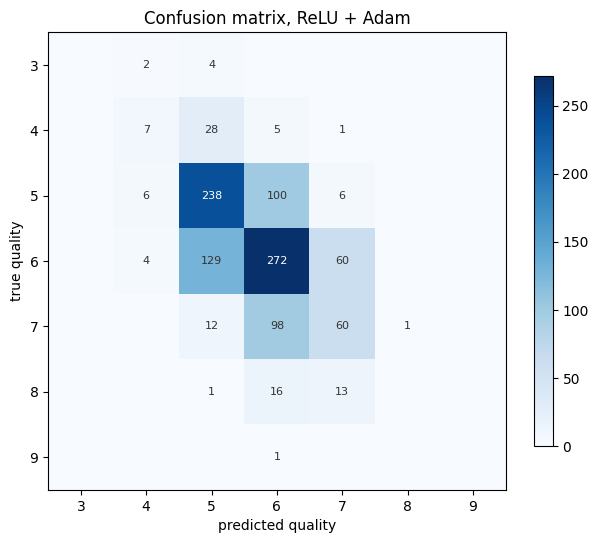

In [ ]:
_, best = train('relu', 'adam')
pred = best['pred']
cm = confusion_matrix(y_test, pred, labels=range(N_CLASSES))

print("Confusion matrix (rows = true quality, columns = predicted quality)\n")
print("        " + "".join(f"{l:>6}" for l in LABELS))
for i,row in enumerate(cm):
    print(f"true {LABELS[i]:<3}" + "".join(f"{v:>6}" for v in row))

print("\n" + classification_report(y_test, pred, labels=range(N_CLASSES),
                                   target_names=LABELS, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(6.4,5.4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(N_CLASSES), LABELS); ax.set_yticks(range(N_CLASSES), LABELS)
ax.set_xlabel("predicted quality"); ax.set_ylabel("true quality")
ax.set_title("Confusion matrix, ReLU + Adam")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if cm[i,j]:
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()*0.5 else '#333', fontsize=8)
plt.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()

#### Observation
The matrix is the most informative output in the notebook, and it answers the questions the practical asks directly.

**Best predicted class: grade 5**, recall 0.680 and precision 0.578. **Grade 6** follows at recall 0.585. These are the two classes with thousands of training examples.

**Worst: grades 3, 8 and 9, all at recall 0.000.** The model does not predict them even once. Grade 8 is the striking case: 30 test wines, 118 training wines, and not a single correct prediction. Its wines get absorbed into grades 6 and 7.

**The dominant confusions are 5 with 6, and 6 with 7.** The off-diagonal mass sits almost entirely in the cells immediately adjacent to the diagonal.

Note macro F1 0.259 against weighted F1 0.525. The same predictions, scored two ways, differ by a factor of two. Macro averaging treats grade 9 (1 sample) as equal in importance to grade 6 (465 samples), so the three unlearned classes drag it down. Weighted averaging effectively reports how well the model does on grades 5 and 6 and hides the rest.

## The result that reframes the whole model

53% accuracy on seven classes sounds like a poor model. But the confusion matrix above is not scattered, the mass sits tightly along the diagonal and its immediate neighbours.

Quality grades are **ordinal**: grade 6 sits between 5 and 7, and confusing a 5 with a 6 is a completely different kind of mistake from confusing a 3 with an 8. Standard accuracy treats both as equally wrong.

So the question worth asking is not "how often is it right" but **"when it is wrong, how wrong is it?"**

In [ ]:
err  = pred != y_test
dist = np.abs(pred - y_test)

print(f"total errors: {err.sum()} out of {len(y_test)} test wines\n")
for d in range(1, int(dist.max())+1):
    n = (dist == d).sum()
    if n: print(f"  wrong by exactly {d} quality level(s): {n:>4}   ({100*n/err.sum():5.1f}% of all errors)")

print(f"\nstrict accuracy (exact grade)   : {accuracy_score(y_test,pred):.4f}")
print(f"accuracy allowing +-1 grade     : {(dist<=1).mean():.4f}")

pairs = [(LABELS[i], LABELS[j], cm[i,j]+cm[j,i])
         for i in range(N_CLASSES) for j in range(i+1, N_CLASSES)]
pairs.sort(key=lambda t: -t[2])
print("\nMost confused pairs (both directions combined):")
for a,b,n in pairs[:4]:
    print(f"  quality {a} and quality {b}: {n} wines confused")

total errors: 487 out of 1064 test wines

  wrong by exactly 1 quality level(s):  437   ( 89.7% of all errors)
  wrong by exactly 2 quality level(s):   47   (  9.7% of all errors)
  wrong by exactly 3 quality level(s):    3   (  0.6% of all errors)

strict accuracy (exact grade)   : 0.5423
accuracy allowing +-1 grade     : 0.9530

Most confused pairs (both directions combined):
  quality 5 and quality 6: 229 wines confused
  quality 6 and quality 7: 158 wines confused
  quality 4 and quality 5: 34 wines confused
  quality 5 and quality 7: 18 wines confused


#### Observation
**89.7% of every mistake the model makes is off by exactly one grade.** Only 3 errors out of 487 are off by 3 or more.

```
strict accuracy (exact grade) : 0.5423
accuracy allowing +-1 grade   : 0.9530
```

That reframes the model completely. A 54% classifier sounds barely usable. A model that places **95.3% of wines within one grade of the human panel** is a different description of the same predictions, and it is the more informative one, because the target is ordinal.

The most confused pairs are exactly the adjacent ones: **grades 5 and 6 (229 wines), grades 6 and 7 (158 wines)**. Together those two pairs account for 387 of the 487 errors, about 79%.

**Why this happens is a property of the labels, not a flaw in the network.** Each grade is the median of at least three human tasters. A wine sitting on the boundary between "average" and "good" will genuinely split a tasting panel, and whichever way the median falls becomes the label. The chemical measurements for a borderline 5 and a borderline 6 are close to identical, so no model can separate them reliably. The label itself carries the ambiguity.

## How class imbalance shapes the result

Two questions follow from the class distribution. First, how much does the choice of averaging change the reported score. Second, whether reweighting the rare classes actually fixes anything.

In [ ]:
print("Same predictions, three different averaging choices:\n")
for avg in ['macro','weighted','micro']:
    print(f"  {avg:<9} precision {precision_score(y_test,pred,average=avg,zero_division=0):.4f}"
          f"   recall {recall_score(y_test,pred,average=avg,zero_division=0):.4f}"
          f"   F1 {f1_score(y_test,pred,average=avg,zero_division=0):.4f}")

cw_arr = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_train)
cw = {i: w for i, w in enumerate(cw_arr)}
print("\nBalanced class weights (how much each class is upweighted):")
print("  " + "  ".join(f"q{CLASSES[i]}:{w:.1f}" for i,w in cw.items()))

acc_u, f1_u, acc_w, f1_w = [], [], [], []
for s in SEEDS:
    _, ru = train('relu','adam', seed=s)
    _, rw = train('relu','adam', seed=s, class_weight=cw)
    acc_u.append(ru['test_acc']); f1_u.append(ru['f1'])
    acc_w.append(rw['test_acc']); f1_w.append(rw['f1'])

print(f"\n{'':<14}{'accuracy':>10}{'macro F1':>11}")
print(f"{'unweighted':<14}{np.mean(acc_u):>10.4f}{np.mean(f1_u):>11.4f}")
print(f"{'class-weighted':<14}{np.mean(acc_w):>10.4f}{np.mean(f1_w):>11.4f}")
print(f"{'change':<14}{np.mean(acc_w)-np.mean(acc_u):>+10.4f}{np.mean(f1_w)-np.mean(f1_u):>+11.4f}")
print(f"\nfor reference, run-to-run macro F1 spread on this config: {np.ptp(stab[('relu','adam')][1]):.4f}")

Same predictions, three different averaging choices:

  macro     precision 0.2754   recall 0.2552   F1 0.2589
  weighted  precision 0.5147   recall 0.5423   F1 0.5249
  micro     precision 0.5423   recall 0.5423   F1 0.5423

Balanced class weights (how much each class is upweighted):
  q3:25.3  q4:3.7  q5:0.4  q6:0.3  q7:0.9  q8:5.2  q9:152.0



                accuracy   macro F1
unweighted        0.5354     0.2576
class-weighted    0.4167     0.2655
change           -0.1187    +0.0078

for reference, run-to-run macro F1 spread on this config: 0.0363


#### Observation
**On averaging.** The same predictions score 0.2589 (macro), 0.5249 (weighted) or 0.5423 (micro). Micro F1 equals accuracy exactly, which is always true in single-label multiclass. Reporting only weighted F1 would hide that three classes are never predicted at all, which is why macro is used throughout this notebook.

**On class weighting.** Upweighting the rare classes is the standard remedy, and here it costs far more than it returns: accuracy falls by **11.87 percentage points** while macro F1 rises by **0.0078**.

That gain has to be read against the run-to-run spread on this configuration, which is **0.0363**. The improvement is roughly five times smaller than the noise, so it is not distinguishable from nothing.

**Why reweighting fails here.** Class weights change how much each mistake is penalised; they do not create information. Grade 9 has four training wines. Multiplying its loss contribution by 152 makes the model guess that class more often, scattering predictions across the confident middle classes and destroying accuracy, without giving it anything new to learn from. When the problem is a shortage of examples rather than a shortage of emphasis, reweighting is the wrong tool.

## How the number of classes changes the problem

If the errors really are concentrated between adjacent grades, then merging adjacent grades should recover most of the lost accuracy. That is a prediction the previous section makes, and it can be tested directly.

Grades are collapsed into three bands: low (3 to 5), medium (6), high (7 to 9). Same features, same architecture, same split procedure.

In [ ]:
df_binned = df_clean.copy()
df_binned['quality'] = pd.cut(df_binned['quality'], bins=[0,5,6,10], labels=[0,1,2]).astype(int)
Xb_tr, Xb_te, yb_tr, yb_te, B_CLASSES, _ = prepare(df_binned)

print("3-class distribution:", {f"band {b}": int((df_binned['quality']==b).sum()) for b in [0,1,2]})
mb = quick_model(Xb_tr, yb_tr, len(B_CLASSES))
pb = mb.predict(Xb_te, verbose=0).argmax(1)

maj_b = np.bincount(yb_tr).argmax()
print(f"\n{'setup':<26}{'classes':>9}{'majority base':>15}{'accuracy':>10}{'macro F1':>10}")
print("-"*70)
print(f"{'original grades':<26}{N_CLASSES:>9}{100*np.bincount(y_train).max()/len(y_train):>14.1f}%"
      f"{accuracy_score(y_test,pred):>10.4f}{f1_score(y_test,pred,average='macro',zero_division=0):>10.4f}")
print(f"{'merged into 3 bands':<26}{len(B_CLASSES):>9}{100*np.bincount(yb_tr).max()/len(yb_tr):>14.1f}%"
      f"{accuracy_score(yb_te,pb):>10.4f}{f1_score(yb_te,pb,average='macro',zero_division=0):>10.4f}")

3-class distribution: {'band 0': 1988, 'band 1': 2323, 'band 2': 1009}



setup                       classes  majority base  accuracy  macro F1
----------------------------------------------------------------------
original grades                   7          43.7%    0.5423    0.2589
merged into 3 bands               3          43.7%    0.5893    0.5828


#### Observation
Merging the seven grades into three bands lifts accuracy from 0.5423 to **0.5893**, but the striking change is macro F1, which goes from 0.2589 to **0.5828**, more than doubling.

**This confirms the prediction from the adjacent-error analysis.** The information needed to separate a 5 from a 6 was never in the chemical measurements; merging them removes a distinction the features cannot support. The macro F1 jump is larger than the accuracy jump because binning also eliminates the tiny classes: grades 3 and 4 fold into "low" and grades 8 and 9 into "high", so every class now has enough examples to learn.

The majority baseline stays at 43.7%, so this is not a case of the task becoming trivially easy. It is the same problem asked at a resolution the data can actually answer.

**The practical lesson about the number of classes:** more classes is not automatically a harder version of the same problem. Here it is a partly unanswerable version, because two of the seven classes have almost no examples and several neighbouring pairs are not distinguishable from the features at all.

## Training and validation curves

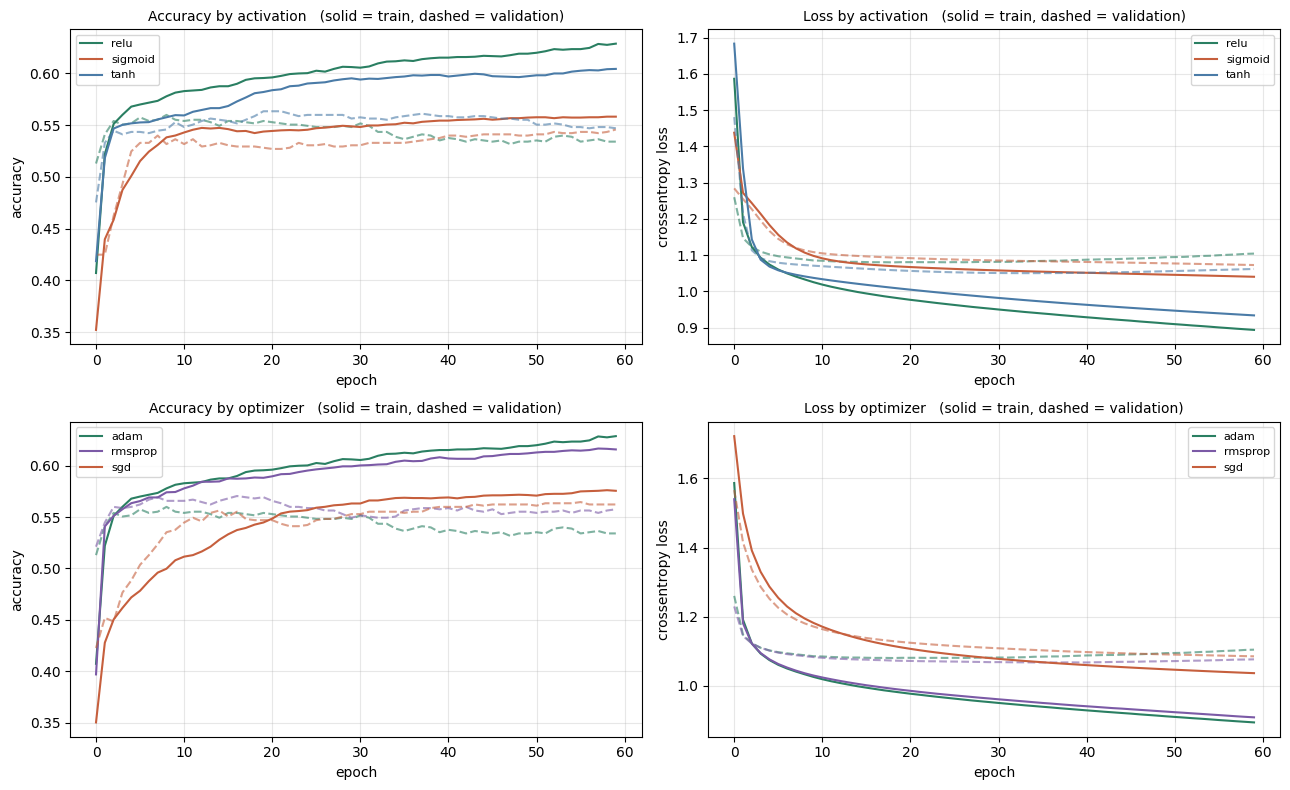

configuration       train acc   val acc      gap
relu + adam            0.6287    0.5340   0.0946
sigmoid + adam         0.5582    0.5458   0.0124
tanh + adam            0.6043    0.5469   0.0573
relu + rmsprop         0.6157    0.5575   0.0582
relu + sgd             0.5755    0.5622   0.0133


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colA = {'relu':'#2a7f62','sigmoid':'#c65f3d','tanh':'#4a7ba7'}
colO = {'adam':'#2a7f62','rmsprop':'#7b5aa6','sgd':'#c65f3d'}

for a in ACTS:
    axes[0,0].plot(actA[a]['hist']['accuracy'], color=colA[a], label=a)
    axes[0,0].plot(actA[a]['hist']['val_accuracy'], color=colA[a], ls='--', alpha=0.6)
    axes[0,1].plot(actA[a]['hist']['loss'], color=colA[a], label=a)
    axes[0,1].plot(actA[a]['hist']['val_loss'], color=colA[a], ls='--', alpha=0.6)
for o in OPTS:
    axes[1,0].plot(optB[o]['hist']['accuracy'], color=colO[o], label=o)
    axes[1,0].plot(optB[o]['hist']['val_accuracy'], color=colO[o], ls='--', alpha=0.6)
    axes[1,1].plot(optB[o]['hist']['loss'], color=colO[o], label=o)
    axes[1,1].plot(optB[o]['hist']['val_loss'], color=colO[o], ls='--', alpha=0.6)

for ax,t,yl in [(axes[0,0],"Accuracy by activation","accuracy"),
                (axes[0,1],"Loss by activation","crossentropy loss"),
                (axes[1,0],"Accuracy by optimizer","accuracy"),
                (axes[1,1],"Loss by optimizer","crossentropy loss")]:
    ax.set_title(t + "   (solid = train, dashed = validation)", fontsize=10)
    ax.set_xlabel("epoch"); ax.set_ylabel(yl); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'configuration':<18}{'train acc':>11}{'val acc':>10}{'gap':>9}")
for a in ACTS:
    r=actA[a]; print(f"{a+' + adam':<18}{r['train_acc']:>11.4f}{r['val_acc']:>10.4f}{r['train_acc']-r['val_acc']:>9.4f}")
for o in ['rmsprop','sgd']:
    r=optB[o]; print(f"{'relu + '+o:<18}{r['train_acc']:>11.4f}{r['val_acc']:>10.4f}{r['train_acc']-r['val_acc']:>9.4f}")

#### Observation: overfitting, underfitting and convergence
The gap column separates the configurations more clearly than any accuracy figure did.

**Overfitting: relu + adam**, gap 0.0946. Its training accuracy climbs while validation flattens early, the classic divergence, and the validation loss curve turns upward while training loss keeps falling. This is the model fitting noise in the training set.

**Stable and well matched: relu + sgd (gap 0.0133) and sigmoid + adam (gap 0.0124).** Training and validation move together throughout.

**Poor convergence: sgd early on.** Its curve is visibly still climbing at epoch 5 while the adaptive optimizers have plateaued, which is the same effect the epochs-to-threshold table quantified.

**Mild underfitting: sigmoid.** It has the smallest gap but also the lowest training accuracy (0.5582) and the highest training loss (1.0406), so both curves sit high together. A small gap only indicates health when the loss is also low.

Note that validation accuracy peaks within the first handful of epochs for every configuration and then flattens or drifts down. Training for 60 epochs is generous, and early stopping around epoch 10 would give essentially the same test performance for a sixth of the compute.

## Analysis and interpretation

**1. Which activation function performed best, and why?**
None of them, meaningfully. Tanh leads on a single run (0.5442) but across 3 seeds all three sit within 0.008 of each other, while one configuration alone varies by up to 0.0169 on seed. This problem is not limited by the activation. ReLU does fit the training data hardest, which shows as the largest train/validation gap rather than better test accuracy.

**2. Which optimizer performed best, and why?**
For accuracy, no meaningful difference (0.5370 to 0.5451). For convergence, Adam and RMSprop clearly win, reaching 54% validation at epoch 2 against SGD's epoch 11, because they adapt the step size per weight. For generalisation, plain SGD wins, gap 0.0133 against Adam's 0.0946.

**3. Best combination?**
ReLU with SGD: joint-best accuracy (0.5451) with the smallest overfitting gap. Its cost is needing five times more epochs.

**4. Did the activation affect convergence?**
Only mildly. All three plateau within a few epochs under Adam. Unlike Practical 6, where sigmoid was measurably gradient-starved, the softmax output and shallow depth keep gradients healthy here.

**5. Did the optimizer affect convergence speed?**
Yes, decisively. Adam and RMSprop pass 54% at epoch 2, SGD at epoch 11. At epoch 5 SGD is still at 0.4883, below the majority baseline, while the others sit at 0.55.

**6. Best validation performance?**
ReLU + RMSprop at 0.5575, with ReLU + SGD at 0.5622 on its own run. Both inside the noise band.

**7. Best test performance?**
ReLU + Adam and ReLU + SGD tie at 0.5451 over 3 seeds.

**8. Significant train/test difference?**
Entirely optimizer-dependent. ReLU + Adam: 0.6287 train, 0.5340 validation, gap 0.0946. ReLU + SGD: 0.5755 and 0.5622, gap 0.0133. Same architecture, seven times the gap.

**9. Overfitting or underfitting?**
Both, by configuration. ReLU + Adam overfits (widening gap, validation loss rising). Sigmoid underfits (both curves high and close). ReLU + SGD is best fitted.

**10. Which classes were most misclassified?**
Grades 3, 8 and 9 are never predicted correctly, recall 0.000 each. By volume the largest error counts are grades 5 and 6, since they hold the most wines. Most confused pairs: 5 with 6 (229 wines), 6 with 7 (158).

**11. Why those misclassifications?**
Three separate causes. **Too few examples:** grades 3, 8 and 9 have 24, 118 and 4 training rows. **Overlapping classes:** grades are ordinal and adjacent ones differ by less than the chemistry resolves, hence 89.7% of errors being off by one. **Label noise:** each grade is a median of at least three tasters, so borderline wines carry the panel's disagreement in the label.

**12. What would improve performance?**
Merging adjacent grades, tested above: 3 bands lifts macro F1 from 0.2589 to 0.5828. Treating the target as ordinal so predicting 5 for a 6 costs less than predicting 3. Collecting more rare-grade examples, since reweighting the existing ones does not work. Early stopping near epoch 10 for the same accuracy at a sixth of the compute.

**13. Which model would you select?**
See below.

## Final model selection

**Selected model: ReLU activation with plain SGD.**

Accuracy cannot separate these models, since all five sit inside the noise band, so the decision rests on generalisation and stability.

| criterion | why SGD wins |
|---|---|
| Test accuracy | 0.5451, joint best across 3 seeds |
| Generalisation gap | **0.0133**, seven times smaller than Adam's 0.0946 |
| Stability across seeds | spread 0.0056, versus 0.0169 for ReLU + Adam |
| Learning curves | train and validation move together, no divergence |
| Model complexity | identical across all configurations, so not a differentiator |

**The cost:** SGD needs about 11 epochs where Adam needs 2. On 4256 rows that is seconds, so the trade is worth taking. On a much larger dataset it might not be.

**Macro F1 was deliberately not the deciding metric.** ReLU + RMSprop posts the highest value (0.2595) but also the largest seed-to-seed swing (0.0444), so that lead is untrustworthy.

**What I would actually deploy** is the 3-band version, macro F1 0.5828 against 0.2589, because it asks a question the data can support.

### Personal notes

**The stability check is the result I would defend, and it is the one I nearly skipped.** After Experiments A and B I had two clean tables with a ranking in each, and writing up "tanh performed best, Adam converged fastest" would have satisfied the brief. Repeating each configuration across three seeds showed the between-configuration spread (0.0081) is less than half the within-configuration spread (0.0169), so that ranking was noise. Same mistake I made in Practical 4 with a scaling claim, which is why the repeat-check is now built in rather than an afterthought.

**Being unable to declare a winner is a finding, not a failure.** The instinct is to produce a ranking because the question asks for one. The useful statement is that activation and optimizer barely matter here while the data properties dominate, and that is only sayable because the noise was measured.

**The +-1 analysis changed how I read the model.** 54% looked weak until I checked how wrong the errors were. 89.7% off by exactly one grade, 95.3% within one grade, says the model is near the ceiling the labels allow. Standard accuracy cannot express that, because it treats an ordinal target as unrelated categories.

**I expected class weighting to work and it did not.** 11.87 points of accuracy spent for a macro F1 gain five times smaller than the noise. Obvious in hindsight: weighting changes the penalty, not the evidence, and grade 9 has four training wines.

**What I would do differently:** treat the target as ordinal from the start. Crossentropy penalises predicting 5 instead of 6 exactly as harshly as predicting 3 instead of 9, which discards the ordering, and the confusion matrix shows the ordering is nearly all the structure in this problem.

#### Conclusion
- Architecture is unchanged from Practical 4: two hidden layers, one output neuron per class, **softmax** so the seven outputs form a probability distribution. What is new is that the data is real and difficult rather than generated from rules.
- Baselines: random 14.3%, **majority class 43.70%**, logistic regression 53.20%. The MLP reaches about 54.5%, so hidden layers add little over a linear model here.
- **Removing 18.1% duplicate rows costs 1.7 points**, which was leakage rather than performance.
- **No activation or optimizer choice meaningfully changed accuracy.** Spread across five configurations (0.0081) is less than half the spread from changing the seed within one (0.0169).
- **The optimizer does change convergence and overfitting.** Adam and RMSprop hit 54% validation at epoch 2, SGD at epoch 11, but SGD ends with a gap of 0.0133 against Adam's 0.0946.
- **89.7% of errors are off by exactly one grade** and accuracy within one grade is **95.3%**. Dominant confusions are 5 with 6 and 6 with 7, adjacent and genuinely ambiguous to human tasters.
- **Three classes are never predicted** (grades 3, 8, 9), with 24, 118 and 4 training rows. Macro F1 0.259 against weighted 0.525 is the same predictions scored two ways.
- **Class weighting does not fix imbalance**, costing 11.87 points of accuracy for a macro F1 gain five times smaller than the noise.
- **Merging to 3 bands more than doubles macro F1** (0.2589 to 0.5828).
- Final selection is **ReLU + SGD**, on generalisation and stability rather than accuracy.